# Examples merge

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# Standard imports
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import pandas as pd
import numpy as np
import xarray as xr
import string 
import tqdm 
import gc

In [3]:
import sys
import os

# # Add the poligrain and mergeplg src directories to Python's path
sys.path.insert(0, os.path.abspath("./mergeplg/src"))
sys.path.insert(0, os.path.abspath("./poligrain/src"))
sys.path.insert(0, os.path.abspath("./pycomlink"))

# Import submodules
import pycomlink as pycml
import poligrain as plg
from mergeplg import interpolate, merge

## Download relevant data

In [4]:
# Use gdown to iterate through folder, we will replace this later
!pip install --quiet gdown

In [5]:
# Individual data files, {where to store: download_id}
file_ids = {
    './data/cml/cml.nc': '1MqH4Dzb7Ff-inpWNWQyOFHBWDCO5uKfc',
    './data/radar/radar.nc': '168zv5u9Qb4eZ5W62CuKmHrWyTSS3Z9U2',
    './data/gauges/city_gauge.nc': '1190fQu3ie_93e7iJpZEC-p92h9y8XtOW',     
    './data/gauges/smhi_gauge.nc': '1j7MdStiY1xdWeJrrsEXgHCqMoT9Qy67z',    
   # './data/era5/era5.nc': '1ryNLVox1me_5orrAaTHw8-nROkhpffw1',    
   # './data/gpm_imerg/gpm_imerg_early.nc': '1rck6vKonptGsV9sPauRmzrAmtD1Xan_u',
   # './data/gpm_imerg/gpm_imerg_final.nc': '1zOZD5wPezuVIXl-PaUFWvUrM_cn_O2Nq',    
   # './data/seviri/seviri.nc': '1aeSovV7K-H5i0sHmpdqFYHsX0zgHmRXC',
   # './data/netatmo/netatmo_pressure.nc': '1gq_wFdCOyF697teOEYGH8yg8mTgvvzOa',
   # './data/netatmo/netatmo_temp.nc': '1AhFxkOxqpyNBOhLFHm4f7lpSA745imwI',
   # './data/netatmo/netatmo_humidity.nc': '12fw2nO1f_BRDm3sLKJDfsIKRYl65RRLQ',
    './data/netatmo/netatmo_rain.nc': '1hjJq5sdHBDjNvw5oeLMXVjkdH-P36cpC',
   # './data/netatmo/netatmo_raw.nc': '1Nc9pMi6zFJ7eN7kJGyJLoU_c7bWRrMWT',
}

for file_path, file_id in file_ids.items():
    os.makedirs(os.path.dirname(file_path), exist_ok=True)
    if not os.path.exists(file_path):
        print(f"Downloading {file_path} ...")
        !gdown {file_id} -O {file_path}
    else:
        print(f"skip {file_path}")

skip ./data/cml/cml.nc
skip ./data/radar/radar.nc
skip ./data/gauges/city_gauge.nc
skip ./data/gauges/smhi_gauge.nc
skip ./data/netatmo/netatmo_rain.nc


## Process data

### Process radar data

In [6]:
# Load raw radar files
ds_rad = xr.open_dataset("./data/radar/radar.nc")

# Apply marsha- palmer to get rainfall rates
ds_rad["rainfall_radar"] = (10 ** (ds_rad.data / 10) / 200) ** (5 / 8)

# Flip along y axis to work in the grid intersection function
ds_rad["lat"] = (("y", "x"), np.flip(ds_rad.lat.data, axis=0))
ds_rad["rainfall_radar"] = (
    ("time", "y", "x"),
    np.flip(ds_rad.rainfall_radar.data, axis=1),
)

# Convert to 15min resolution
ds_rad_15min = ds_rad[['crs', 'lat', 'lon', 'rainfall_radar']].resample(time='15min', label='right', closed='right').mean()
ds_rad_15min.rainfall_radar.attrs["units"] = "15min rainfall rate [mm/h]"

# Save radar
ds_rad_15min.to_netcdf('data/radar/radar_15min.nc')

In [7]:
# Delete data from memory
del ds_rad_15min
gc.collect()

13

### Process CML data

In [8]:
# Load CML data, select sublink 0 and resample to 1 min resolution
ds_cmls = xr.open_dataset("./data/cml/cml.nc").isel(sublink_id = 0).load().resample(time="1min").first(skipna=True)

# Calculate total loss
ds_cmls["tl"] = ds_cmls.tsl - ds_cmls.rsl

# Interpolate na
ds_cmls['tl'] = ds_cmls.tl.interpolate_na(dim='time', method='linear', max_gap='5min')

# Flag cmls with strong diurnal fluctuations
qc_diurnalcycle = (ds_cmls.tl.rolling(time=60 * 5, center=True).std() > 2).mean(dim="time") > 0.1

# Flag cmls with very noisy periods
qc_noisyperiods = (ds_cmls.tl.rolling(time=60, center=True).std() > 0.8).mean(dim="time") > 0.20

# Drop flagged CMLs
ds_cmls.where(qc_diurnalcycle, drop=True);
ds_cmls.where(qc_noisyperiods, drop=True);

In [9]:
# CML wet/dry detection using radar
da_intersect_weights = plg.spatial.calc_sparse_intersect_weights_for_several_cmls(
    x1_line=ds_cmls.site_0_lon.values,
    y1_line=ds_cmls.site_0_lat.values,
    x2_line=ds_cmls.site_1_lon.values,
    y2_line=ds_cmls.site_1_lat.values,
    cml_id=ds_cmls.cml_id.values,
    x_grid=ds_rad.lon.values,
    y_grid=ds_rad.lat.values,
    grid_point_location='center',
)

da_radar_along_cmls = plg.spatial.get_grid_time_series_at_intersections(
    grid_data=ds_rad.rainfall_radar, # In mm/h
    intersect_weights=da_intersect_weights,
).resample(time = '1min').bfill()

# Set wet periods above threshold
ds_cmls['wet_radar']  = (da_radar_along_cmls > 0.01).rolling(time=5, center=True).max()

In [10]:
# CML wet/dry detection using CML tl
roll_std_dev = ds_cmls.tl.rolling(time=60, center=True).std()
threshold = 1.12 * roll_std_dev.quantile(0.8, dim="time")
ds_cmls["wet_cml"] = (roll_std_dev > threshold)

/home/erlend/miniforge3/envs/openmrg/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1617: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,


In [11]:
# Estimate baseline
ds_cmls["baseline"] = pycml.processing.baseline.baseline_constant(
    trsl=ds_cmls.tl,
    wet=ds_cmls.wet_cml.astype(bool)| ds_cmls.wet_radar.astype(bool), # wet period if radar or CML is wet
    n_average_last_dry=5,
)

ds_cmls["A_obs"] = ds_cmls.tl - ds_cmls.baseline
ds_cmls["A_obs"] = ds_cmls.A_obs.where(ds_cmls.A_obs >= 0, 0)

# WAA using Pastorek with parameters that looks good 
ds_cmls["waa"] = pycml.processing.wet_antenna.waa_pastorek_2021_from_A_obs(
    A_obs=ds_cmls.A_obs,
    f_Hz=ds_cmls.frequency * 1e6,
    pol=ds_cmls.polarization.data,
    L_km=ds_cmls.length / 1000,
    A_max=6,
    zeta=0.7,  
    d=0.15,
)

# Calculate attenuation caused by rain and remove negative attenuation
ds_cmls["A"] = ds_cmls.tl - ds_cmls.baseline - ds_cmls.waa
ds_cmls["A"].data[ds_cmls.A < 0] = 0

# Derive rain rate via the k-R relation
ds_cmls["R"] = pycml.processing.k_R_relation.calc_R_from_A(
    A=ds_cmls.A,
    L_km=ds_cmls.length.astype(float) / 1000,  # convert to km
    f_GHz=ds_cmls.frequency / 1000,  # convert to GHz
    pol=ds_cmls.polarization,
)

In [12]:
# Resample to 15 min resolution
ds_cmls_15min = ds_cmls.R.resample(time="15min", label='right', closed='right').mean(skipna=True).to_dataset()
ds_cmls_15min.R.attrs["units"] = "15min rainfall rate [mm/h]"

# Save CML
ds_cmls_15min.to_netcdf('data/cml/cml_15min.nc')

In [13]:
# Delete data from memory
del ds_cmls_15min
gc.collect()

38902

### Process rain gauge data

In [14]:
# Load city rain gauge data, unit is sum rainfall / minute
ds_gauges_city = xr.open_dataset('./data/gauges/city_gauge.nc').load()

# Resample city rain gauge data to 15min mm/h
ds_gauges_city = ds_gauges_city.resample(time="15min", label="right", closed="right").mean()*60

In [15]:
# Load SMHI data, unit is sum rainfall / 15min
ds_gauges_smhi = xr.open_dataset('./data/gauges/smhi_gauge.nc').load()

# Scale to mm/h
ds_gauges_smhi['rainfall_amount'] = ds_gauges_smhi.rainfall_amount*4


In [16]:
# Concat city and smhi data
ds_gauges_15min = xr.concat([ds_gauges_city, ds_gauges_smhi], dim="id")

# Rename variable
ds_gauges_15min = ds_gauges_15min.rename({"rainfall_amount": "R"})

# Save rain gauge data
ds_gauges_15min.to_netcdf('data/gauges/gauge_15min.nc')

In [17]:
# Delete data from memory
del ds_gauges_15min
gc.collect()

32

### Process NETATMO rain data

In [18]:
# Load NETATMO data
ds_netatmo_rain = xr.open_dataset('./data/netatmo/netatmo_rain.nc').load()

# Get elevation values (assume they are in order)
elev_values = ds_netatmo_rain['elevation'].values

# Assign elevation as a coordinate of id, removes erronous dimension
ds_netatmo_rain = ds_netatmo_rain.assign_coords(elevation=('id', elev_values))

# Rename coordiantes to comply with opensense standard
ds_netatmo_rain = ds_netatmo_rain.rename({
    'latitude':'lat', 
    'longitude':'lon',
    'rainfall': 'R',
})

# Resample rainfall data to mm/h per 15min
ds_netatmo_rain_15min = ds_netatmo_rain.resample(time="15min", label="right", closed="right").mean()*12

# Save netatmo rain gauge data
ds_netatmo_rain_15min.to_netcdf('data/netatmo/netatmo_rain_15min.nc')

In [19]:
# Delete data from memory
del ds_netatmo_rain_15min
gc.collect()

12

## Select data range and project coordinates

In [20]:
# Focus on small time window
start = '2015-06-01T00:15'
end = '2015-09-01T00:00'

# Load datasets
ds_gauges = xr.open_dataset('./data/gauges/gauge_15min.nc').sel(time = slice(start, end))
ds_rad = xr.open_dataset('./data/radar/radar_15min.nc').sel(time = slice(start, end))
ds_cmls = xr.open_dataset('./data/cml/cml_15min.nc').sel(time = slice(start, end))
ds_pws = xr.open_dataset('./data/netatmo/netatmo_rain_15min.nc').sel(time = slice(start, end))

In [21]:
# UTM32N: https://epsg.io/32632
ref_str = "EPSG:32632"

# Project rain gauge 
ds_gauges.coords["x"], ds_gauges.coords["y"] = plg.spatial.project_point_coordinates(
    ds_gauges.lon, ds_gauges.lat, ref_str
)

# Project CML 
(
    ds_cmls.coords["site_0_x"],
    ds_cmls.coords["site_0_y"],
) = plg.spatial.project_point_coordinates(
    ds_cmls.site_0_lon, ds_cmls.site_0_lat, ref_str
)
(
    ds_cmls.coords["site_1_x"],
    ds_cmls.coords["site_1_y"],
) = plg.spatial.project_point_coordinates(
    ds_cmls.site_1_lon, ds_cmls.site_1_lat, ref_str
)
ds_cmls.coords["x"] = (ds_cmls.site_0_x + ds_cmls.site_1_x) / 2
ds_cmls.coords["y"] = (ds_cmls.site_0_y + ds_cmls.site_1_y) / 2

# Project radar 
ds_rad.coords["x_grid"], ds_rad.coords["y_grid"] = plg.spatial.project_point_coordinates( 
    ds_rad.lon, ds_rad.lat, ref_str
)

# Project PWS
ds_pws.coords["x"], ds_pws.coords["y"] = plg.spatial.project_point_coordinates(
    ds_pws.lon, ds_pws.lat, ref_str
)


## Merge radar and ground observations

In [22]:
# Define variogram parameters used by kriging
variogram_parameters = {"sill": 1, "range": 30000, "nugget": 0.3}
variogram_model = "spherical"

# Number of neighbours to use for interpolation
nnear = 12

In [23]:
# Merge PWS and radar data using additive merging
merger = merge.MergeDifferenceIDW(
    ds_rad=ds_rad.rainfall_radar,
    ds_gauges=ds_pws,
    nnear=nnear,
    method="additive",
)

rainfall = []
for time in ds_cmls.time.data:
    rainfall.append(
        merger(
            ds_rad.sel(time=time).rainfall_radar,
            da_gauges=ds_pws.sel(time=time).R,
        )
    )
ds_rad["rainfall_MergePWS"] = xr.concat(rainfall, dim="time")

In [24]:
# Merge CML and radar data using additive merging
merger = merge.MergeDifferenceIDW(
    ds_rad=ds_rad.rainfall_radar,
    ds_cmls=ds_cmls,
    nnear=nnear,
    method="additive",
)

rainfall = []
for time in ds_cmls.time.data:
    rainfall.append(
        merger(
            ds_rad.sel(time=time).rainfall_radar,
            da_cmls=ds_cmls.sel(time=time).R,
        )
    )
ds_rad["rainfall_MergeCML"] = xr.concat(rainfall, dim="time")

In [25]:
# Save merged fields with compression
folder_path = 'data/merge/'
os.makedirs(folder_path, exist_ok=True)

ds_rad.to_netcdf(
    path='data/merge/merge_15min.nc',
    encoding={
        'rainfall_MergePWS': {
            'dtype': 'int32',
            'scale_factor': 0.001,
            '_FillValue': -9999,
            'zlib': True,
            'complevel': 2},
        'rainfall_MergeCML': {
            'dtype': 'int32',
            'scale_factor': 0.001,
            '_FillValue': -9999,
            'zlib': True,
            'complevel': 2},
    }
)

In [26]:
# Delete data from memory
del ds_rad
gc.collect()

20

# Plot rainfall fields

In [27]:
# Focus on small time window
start = '2015-06-01T00:15'
end = '2015-09-01T00:00'

# Load datasets
ds_gauges = xr.open_dataset('./data/gauges/gauge_15min.nc').sel(time = slice(start, end))
ds_rad = xr.open_dataset('./data/radar/radar_15min.nc').sel(time = slice(start, end))
ds_cmls = xr.open_dataset('./data/cml/cml_15min.nc').sel(time = slice(start, end))
ds_pws = xr.open_dataset('./data/netatmo/netatmo_rain_15min.nc').sel(time = slice(start, end))
ds_merge = xr.open_dataset('./data/merge/merge_15min.nc').sel(time = slice(start, end))

# Move merged fields to ds_rad for simpler plotting 
ds_rad = ds_rad.rename_vars({'rainfall_radar': 'rainfall_Radar'})
ds_rad['rainfall_MergePWS'] = ds_merge.rainfall_MergePWS
ds_rad['rainfall_MergeCML'] = ds_merge.rainfall_MergeCML

In [28]:
# UTM32N: https://epsg.io/32632
ref_str = "EPSG:32632"

# Project rain gauge 
ds_gauges.coords["x"], ds_gauges.coords["y"] = plg.spatial.project_point_coordinates(
    ds_gauges.lon, ds_gauges.lat, ref_str
)

# Project CML 
(
    ds_cmls.coords["site_0_x"],
    ds_cmls.coords["site_0_y"],
) = plg.spatial.project_point_coordinates(
    ds_cmls.site_0_lon, ds_cmls.site_0_lat, ref_str
)
(
    ds_cmls.coords["site_1_x"],
    ds_cmls.coords["site_1_y"],
) = plg.spatial.project_point_coordinates(
    ds_cmls.site_1_lon, ds_cmls.site_1_lat, ref_str
)
ds_cmls.coords["x"] = (ds_cmls.site_0_x + ds_cmls.site_1_x) / 2
ds_cmls.coords["y"] = (ds_cmls.site_0_y + ds_cmls.site_1_y) / 2

# Project radar 
ds_rad.coords["x_grid"], ds_rad.coords["y_grid"] = plg.spatial.project_point_coordinates( 
    ds_rad.lon, ds_rad.lat, ref_str
)

# Project PWS
ds_pws.coords["x"], ds_pws.coords["y"] = plg.spatial.project_point_coordinates(
    ds_pws.lon, ds_pws.lat, ref_str
)


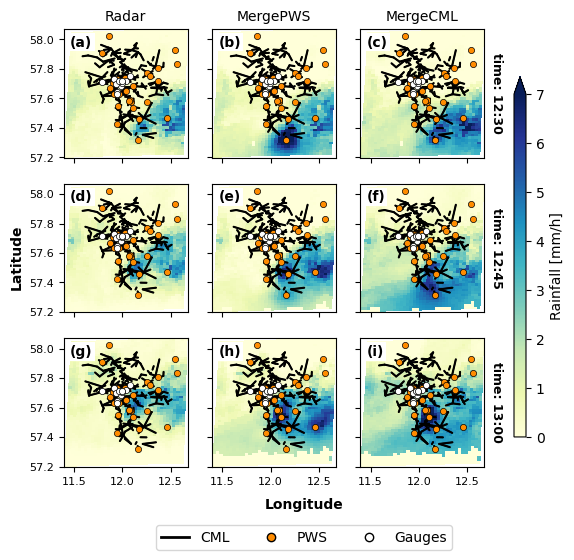

In [29]:
vmax = 7  # max color

# Time interval to plot
time_start = "2015-07-25T12:30"
time_end = "2015-07-25T13:00"

# Rainfall fields to plot
rainfall_fields = [
    "rainfall_Radar",
    "rainfall_MergePWS",
    "rainfall_MergeCML",
]

fig, ax = plt.subplots(
    nrows=ds_cmls.sel(time=slice(time_start, time_end)).time.size, 
    ncols=len(rainfall_fields), 
    figsize=(6, 6), 
    sharey=True,
    sharex=True,
)
for i, rainfall_field in enumerate(rainfall_fields):
    for t, time in enumerate(ds_cmls.sel(time=slice(time_start, time_end)).time):
        # Plot rainfall field
        im = ax[t, i].pcolormesh(
            ds_rad.lon,
            ds_rad.lat,
            ds_rad[rainfall_field].sel(time=time),
            vmin=0,
            vmax=vmax,
            cmap="YlGnBu",
        )

        # Plot postion CMLs
        plg.plot_map.plot_lines(
            ds_cmls,
            use_lon_lat=True,
            ax=ax[t, i],
            line_color="k",
        )
        
        # Plot position PWS
        plg.plot_map.plot_plg(
            da_gauges=ds_pws,
            use_lon_lat=True,
            ax=ax[t, i],
            point_color="darkorange",
        );

        # PLot possition reference raingauges
        plg.plot_map.plot_plg(
            da_gauges=ds_gauges,
            use_lon_lat=True,
            ax=ax[t, i],
            point_color="w",
        );

        # Set size of lat/lon
        ax[t, i].tick_params(axis='both', which='major', labelsize=8)

        # Add timestep info to the right side 
        if i == len(rainfall_fields) - 1:
            # Convert the xarray/numpy time to a readable string
            time_str = 'time: ' + pd.to_datetime(time.values).strftime('%H:%M') 
            
            # Place text to the right of the axis
            ax[t, i].text(1.05, 0.5, time_str, 
                         transform=ax[t, i].transAxes, 
                         va='center', ha='left', 
                         fontsize=9, fontweight='bold',
                         rotation=-90) #

        # Calculate index:
        panel_index = t * len(rainfall_fields) + i
        label = f"({string.ascii_lowercase[panel_index]})"

        ax[t, i].text(
            0.05, 0.95, label, 
            transform=ax[t, i].transAxes, 
            fontsize=10, 
            fontweight='bold',
            va='top', 
            ha='left',
            bbox=dict(facecolor='white', alpha=1, edgecolor='none', pad=1.5)
        )
        
    # Set title
    ax[0, i].set_title(rainfall_field.split("_")[1], fontsize=10)

# Adjust subplots to make space for legend and colorbar
fig.subplots_adjust(bottom=0.15, right=0.8, left=0.1) # Fine-tune these values

# Add colorbar
cbar_ax = fig.add_axes([0.85, 0.2, 0.02, 0.6])
clb = fig.colorbar(im, cax=cbar_ax, extend='max')
clb.ax.set_ylabel("Rainfall [mm/h]", fontsize=10)

# Add x and y label
fig.text(0.5, 0.08, 'Longitude', ha='center', fontsize=10, fontweight='bold')
fig.text(0.01, 0.5, 'Latitude', va='center', rotation='vertical', fontsize=10, fontweight='bold')

# Define the custom legend handles
legend_elements = [
    Line2D([0], [0], color='k', lw=2, label='CML'),
    Line2D([0], [0], marker='o', color='k', markerfacecolor='darkorange', markersize=6, label='PWS', linestyle='None'),
    Line2D([0], [0], marker='o', color='k', markerfacecolor='w', markersize=6, label='Gauges', linestyle='None')
]

# Add the legend to the figure
fig.legend(handles=legend_elements, 
           loc='lower center', 
           ncol=3, 
           fontsize=10, 
           frameon=True,
           bbox_to_anchor=(0.5, 0.00)) # Adjust -0.02 to move it up or down

plt.savefig('./merge_maps.png', dpi=600)

# Compare to rain gauges

In [30]:
get_grid_at_points = plg.spatial.GridAtPoints(
    da_gridded_data=ds_rad,
    da_point_data=ds_gauges,
    nnear=1,
    stat="best",
)

# Sample rainfall fields
for rainfall_field in rainfall_fields:
    ds_gauges[rainfall_field] = get_grid_at_points(
        da_gridded_data=ds_rad[rainfall_field],
        da_point_data=ds_gauges.R,
    )

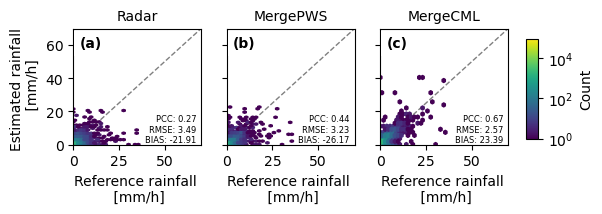

In [31]:
# Plot
threshold = 1  # Estimates below this are ignored
ground_truth = ds_gauges.R.data.flatten()
xymax = 70

fig, ax = plt.subplots(
    1, len(rainfall_fields), figsize=(6, 2), sharey=True, sharex=True
)
for i, rainfall_field in enumerate(rainfall_fields):
    # Get predictions at test gauges
    predicted = ds_gauges[rainfall_field].to_numpy().flatten()

    # plotting the scatter density plots
    hx = ax[i].hexbin(
        ground_truth,
        predicted,
        gridsize=20,
        mincnt=1,
        bins='log',
    )
    ax[i].plot([0, xymax], [0, xymax], color='grey', linestyle='--', linewidth=1, zorder=0)
    ax[i].set_xlim(0, xymax)
    ax[i].set_ylim(0, xymax)

    ax[i].set_title(rainfall_field.split("_")[1], fontsize=10)
    if i == 0:
        ax[i].set_ylabel("Estimated rainfall \n [mm/h]", fontsize=10)
    else:
        ax[i].set_ylabel("")
    ax[i].set_xlabel("Reference rainfall \n [mm/h]", fontsize=10)

    rainfall_metrics = plg.validation.calculate_rainfall_metrics(
        reference=ground_truth,
        estimate=predicted,
        ref_thresh=threshold,
        est_thresh=threshold,
    )

    # adding metrics to the plot for subplot 0
    plotted_metrics = (
        f"PCC: {np.round(rainfall_metrics['pearson_correlation_coefficient'], 2)}\n"
        f"RMSE: {np.round(rainfall_metrics['root_mean_square_error'], 2)}\n"
        f"BIAS: {np.round(rainfall_metrics['percent_bias'], 2)}"
    )

    ax[i].text(
        0.96,
        0.13,
        plotted_metrics,
        fontsize=6,
        transform=ax[i].transAxes,
        verticalalignment="center",
        horizontalalignment="right",
    )
    
    # Add panel labels (a, b, c) 
    label = f"({string.ascii_lowercase[i]})"
    ax[i].text(0.05, 0.84, label, transform=ax[i].transAxes, 
               fontweight='bold', bbox=dict(facecolor='white', alpha=1, edgecolor='none'))

# Add common colorbar
fig.subplots_adjust(right=0.85, bottom=0.3) # Make room on the right
cbar_ax = fig.add_axes([0.88, 0.33, 0.02, 0.5]) # [left, bottom, width, height]
clb = fig.colorbar(hx, cax=cbar_ax)
clb.set_label("Count", fontsize=10)
plt.savefig('./merge_hexbins.png', dpi=600)